# İkinci El Araç Piyasa Analizi ve Fiyat Tahmini

Craigslist'ten toplanmış ~427 bin ilanla uçtan uca bir çalışma: temizleme, iş odaklı EDA,
fiyat tahmin modeli ve şüpheli ilan tespiti.

Bu notebook **hikayeyi** anlatır; iş mantığı `src/` paketlerinde yaşar ve buradan sadece
import edilir. Ağır işlemler yeniden çalıştırılmaz — temiz veri, figürler ve raporlar
`scripts/` üzerinden üretilmiş artifact'lerden yüklenir. Derinlik için: `docs/phase1..4` dokümanları.

**Okuma haritası:** 1) Temizleme kararları → 2) EDA içgörüleri → 3) Model + ablation'lar →
4) Anomali tespiti → 5) Sonuç ve iş önerileri.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Notebook lives in notebooks/; project root is one level up
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

FIG = ROOT / "reports" / "figures"

df = pd.read_parquet(ROOT / "data" / "processed" / "cleaned.parquet")
print(f"Cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")

Cleaned dataset: 197,814 rows x 25 cols


## 1. Veri temizleme kararları

Ham veri 426,880 ilan; temizlik sonrası 197,814 (%46.3 tutma oranı). Düşen her satırın
gerekçesi belgeli — özet kurallar:

| Kural | Eşik | Gerekçe |
|---|---|---|
| Fiyat | 500 – 150,000 $ | 0/1 $ placeholder'lar ve absürt üst uç değerler |
| Yıl | 1970 – 2022 | veri 2021'de toplandı; gelecek yıl = veri hatası |
| Kilometre | 1 – 500,000 mi | 0 mil eski araç imkansız; üst uç veri girişi hatası |
| Title status | clean, rebuilt | salvage/parts fiyat dinamiği tamamen farklı |
| Dedup | VIN + fingerprint | fingerprint SADECE VIN'siz satırlara (aşağıda) |

**Kritik detay — dedup:** aynı (marka, model, fiyat, km) kombinasyonu iki FARKLI VIN'de
görülebilir (iki ayrı araç). Fingerprint dedup'ı VIN'li satırlara da uygulamak 271 gerçek
aracı yanlışlıkla silecekti; bu bir probe script'iyle yakalanıp düzeltildi.

**Referans tarih tuzağı:** araç yaşı `posting_year - year` (2021'e göre), asla bugünün
tarihine göre değil — aksi halde yaş özelliği sessizce bozulur.

In [2]:
# Cleaning thresholds live in src/, not redefined here -- imported as proof
from src.preprocess.cleaner import (
    PRICE_MIN, PRICE_MAX, YEAR_MIN, YEAR_MAX, ODOMETER_MIN, ODOMETER_MAX,
)

print(f"price   : [{PRICE_MIN:,.0f}, {PRICE_MAX:,.0f}] $")
print(f"year    : [{YEAR_MIN}, {YEAR_MAX}]")
print(f"odometer: [{ODOMETER_MIN:,.0f}, {ODOMETER_MAX:,.0f}] mi")

price   : [500, 150,000] $
year    : [1970, 2022]
odometer: [1, 500,000] mi


## 2. EDA — ne öğrendik?

Her figürün altında "bu bir pazar yeri için ne anlama geliyor" yorumu var.
Tam liste `docs/phase2_insights.md` (10 bulgu + metodolojik uyarılar). Burada hikayeyi
taşıyan dördü:

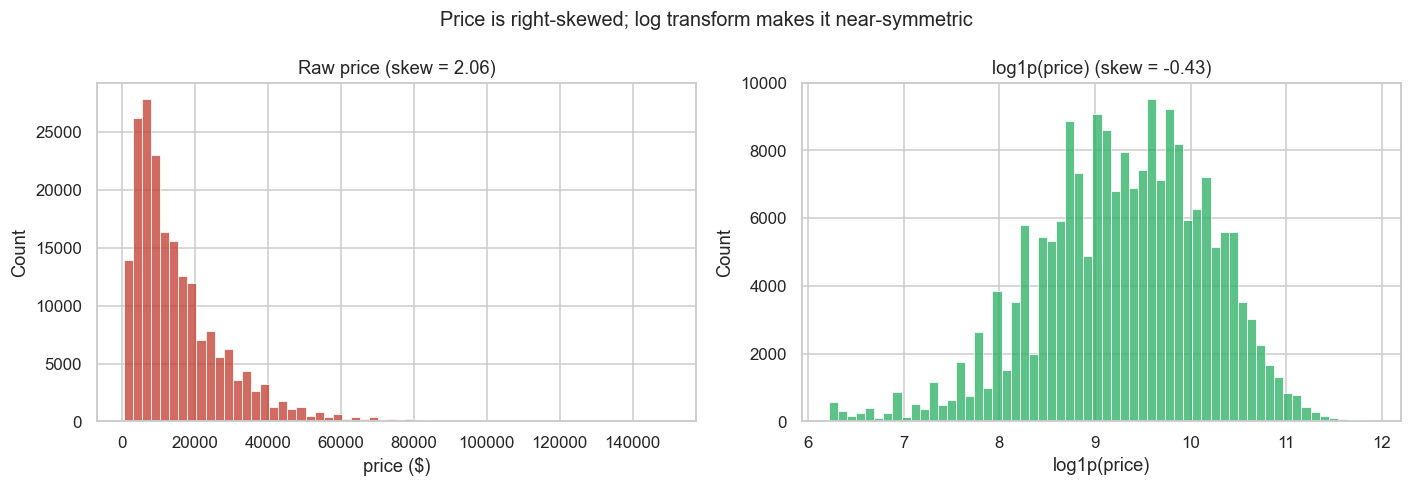

In [3]:
display(Image(FIG / "01_price_distribution.png"))

**Fiyat sağ çarpık (skew 2.06); log dönüşümü simetriye çekiyor (-0.43).**
Ham fiyatla eğitilen model, kaybı pahalı araçların domine etmesine izin verirdi;
log hedef $5k'lık ve $50k'lık araçta yüzdesel hatayı eşit ağırlıklar. (Bu sezgi
Faz 3'te Ablation A1 ile sayısal olarak da test edildi.)

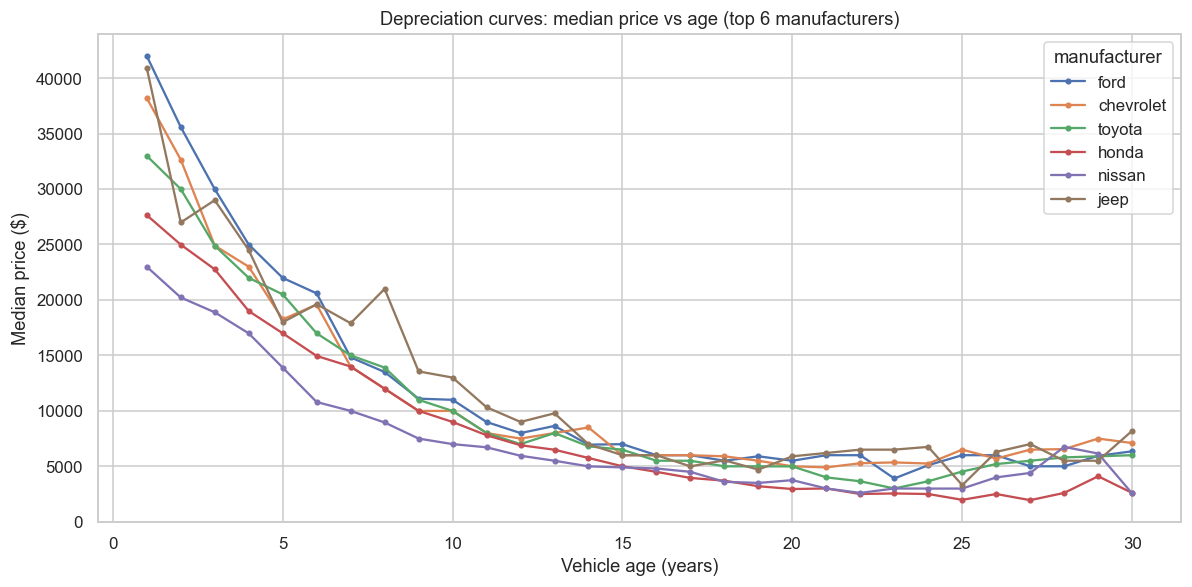

In [4]:
display(Image(FIG / "02_depreciation.png"))

**Değer kaybı öne yüklü:** medyan fiyat 5. yılda %47, 10. yılda %72 aşağıda.
Pazar yeri için anlamı: fiyatlama hatasının en pahalı olduğu segment 0-5 yaş —
model doğruluğu en çok burada önemli.

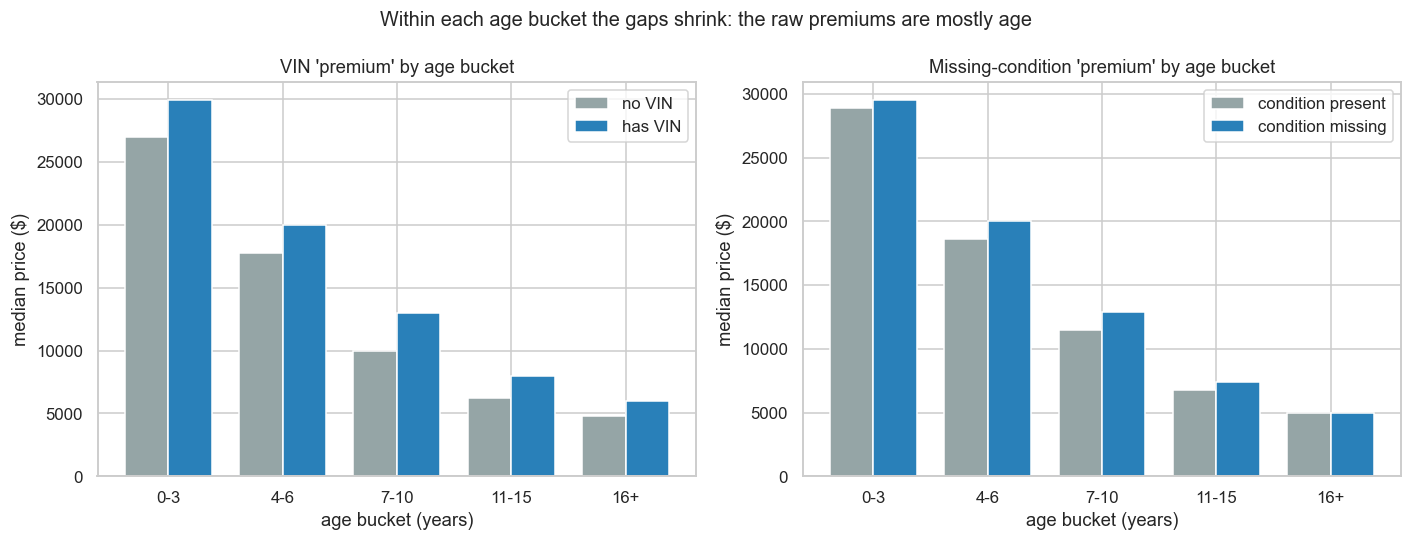

In [5]:
display(Image(FIG / "09_confound_check.png"))

**Tek değişkenli "prim"ler çoğunlukla yaş yanılsaması.** VIN'li ilanlar ham bakışta
1.98x pahalı; aynı yaş kovasında fark 1.29x'e düşüyor. Eksik-condition "primi" aynı şekilde
eriyor. Bu, tek-özellik kurallar (örn. "VIN'li ilan değerlidir") yerine çok değişkenli
modelin temel gerekçesi.

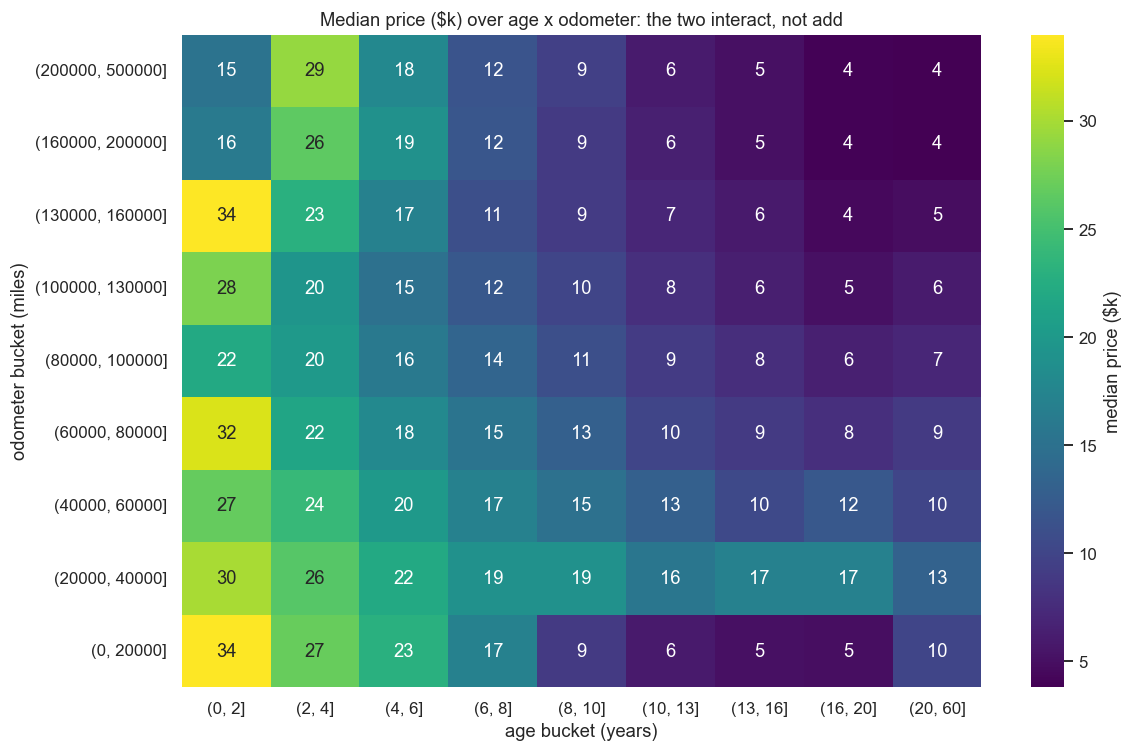

In [6]:
display(Image(FIG / "10_age_odometer_interaction.png"))

**Yaş × kilometre etkileşimli, toplamsal değil.** Düşük km'li eski araç ile yüksek
km'li yeni araç çok farklı fiyatlanır. Lineer (toplamsal) modelin ağaç bazlı modele
kaybedeceğini bu tablo önceden söylüyor — Faz 3 bunu doğruladı.

Diğer bulgular (değer heaping'i: fiyatların %15'i 995 ile bitiyor; kilometrelerin %30'u
yuvarlak bin; eyalet farkları; yapısal eksik veri) için: `docs/phase2_insights.md`.

## 3. Fiyat tahmin modeli

**Kurulum:** hedef `log1p(price)`; split %80/20 random, fiyat desiline göre stratified
(30 günlük tek fotoğraf olduğu için temporal split anlamsız — gerekçe Faz 2'de).
Yüksek kardinaliteli `model` (20,638 değer) için out-of-fold KFold target encoding;
düşük kardinaliteliler one-hot; eksikler median + missing-indicator.

**Sonuçlar** (test seti, dolar ölçeği):

In [7]:
# Final comparison table -- source of truth: docs/phase3_results.md
results = pd.DataFrame({
    "RMSE ($)": [8135, 7082, 6611],
    "MAE ($)": [4411, 3709, 3361],
    "MAPE (%)": [56.2, 45.2, 36.9],
    "R2": [0.63, 0.72, 0.76],
}, index=["Linear Regression", "Random Forest", "LightGBM"])
results

,RMSE ($),MAE ($),MAPE (%),R2
Linear Regression,8135,4411,56.2,0.63
Random Forest,7082,3709,45.2,0.72
LightGBM,6611,3361,36.9,0.76


**Gain bazlı feature importance:** age %45 > model %18 > odometer %9 — EDA'nın
"değer kaybı öne yüklü" bulgusuyla tutarlı, açıklanabilir bir model.

### Ablation'lar: "neden X, Y değil?"

| Soru | Cevap (sayıyla) |
|---|---|
| **A1: Neden log hedef?** | Ham hedef RMSE'de kazanıyor ($6,018 vs $6,611) ama MAPE'de 13 puan kaybediyor (%50 vs %37). İlanların çoğu $20k altı → MAPE öncelikli → log. |
| **A2: Neden `year` atıldı?** | corr(age, year) = -1.00 (inşa gereği). İkisi birlikte konunca katsayılar kararsızlaşıyor (age: -0.026 → +0.239), metrik kazancı yok. |
| **A3: `model` encoding?** | Target encoding $6,611 vs frequency $6,835 vs kolonu atmak $6,802. OOF target encoding açık farkla kazanıyor. |

**Self-review dersi (A3'ün hikayesi):** ilk encoder KFold OOF sonucunu hesaplayıp
kullanmadan tam-train mapping uyguluyordu — yani train satırları kendi etiketini görüyordu.
O sızıntıyla target encoding test'te *kaybediyor görünüyordu*. Düzeltme sonuçları tersine
çevirdi. Ders: **altındaki pipeline sızdırıyorsa ablation güvenilmez.**

Hata analizi (en zayıf segment: $5k altı araçlar, MAPE ~%109; en zayıf markalar:
pickup ağırlıklı Ram/GMC/Ford): `docs/phase3_results.md`.

## 4. Anomali tespiti — şüpheli ilanlar

Etiket yok → doğruluk metriği UYDURMUYORUZ. Bunun yerine iki **birbirinden bağımsız**
sinyal kesiştiriliyor:

1. **Residual sinyali:** ilan fiyatı, modelin 5-fold out-of-fold tahmininden ne kadar
   sapıyor? (log uzayı ≈ yüzdesel hata; eşik MAD tabanlı robust z)
2. **Isolation Forest:** fiyattan BAĞIMSIZ, sadece yapısal özellikler (yaş, km, km/yıl,
   silindir). `log_price` bilerek dışlandı — aksi halde IF, residual sinyalinin
   yakaladığını yeniden yakalar ve kesişim mekanik olarak şişer (kanıt: corr 0.336 → 0.118).

Eşik istatistiksel değil **operasyonel**: dağılım kalın kuyruklu (|z|>3.5 oranı Gaussian'ın
~80 katı), o yüzden eşik "kaç ilanı insan kuyruğu kaldırabilir" sorusunun cevabı.

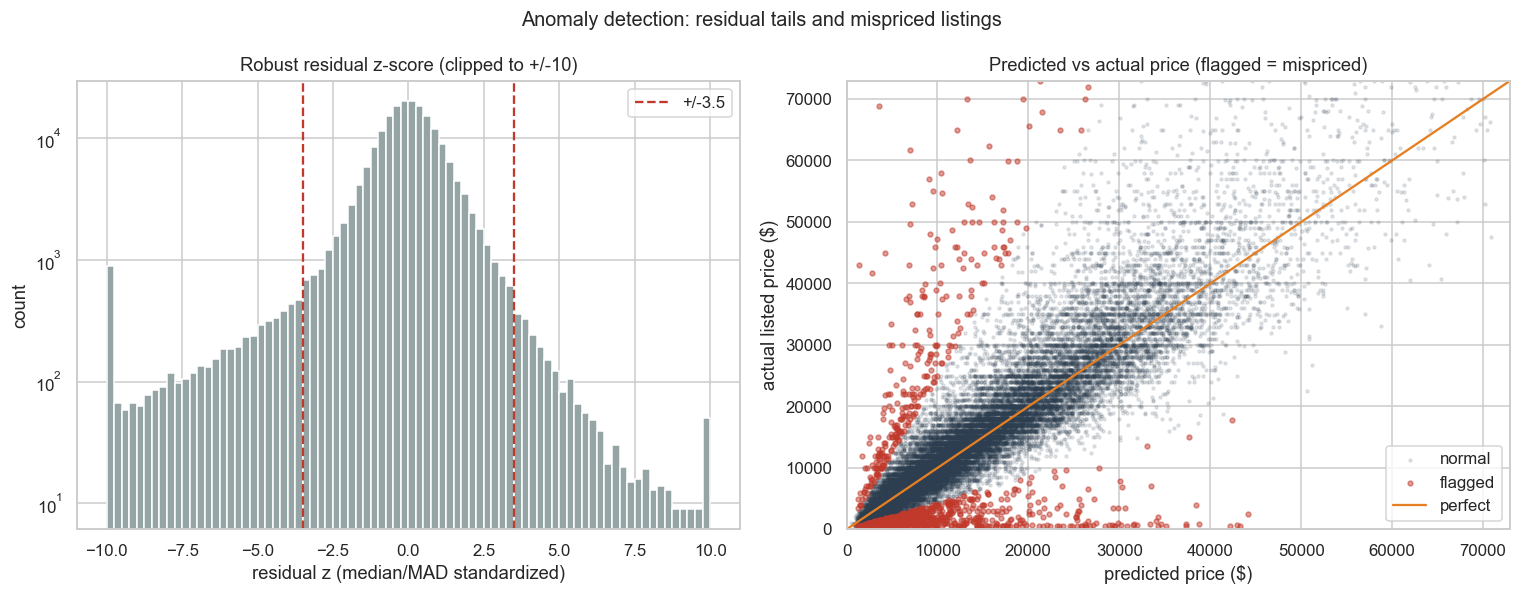

In [8]:
display(Image(FIG / "12_anomaly_overview.png"))

In [9]:
# Top suspicious listings -- generated by scripts/detect_anomalies.py
sus = pd.read_csv(ROOT / "reports" / "suspicious_listings.csv")
cols = ["manufacturer", "model", "year", "odometer", "price",
        "predicted_price", "residual_pct", "priority"]
sus[cols].head(10)

,manufacturer,model,year,odometer,price,predicted_price,residual_pct,priority
0,ram,3500 laramie,2014.0,65862.0,549,50811.0,-98.9,strong mispriced
1,toyota,tacoma trd sport,2018.0,22190.0,512,44158.0,-98.8,strong mispriced
2,rover,sport su,2015.0,55187.0,507,43305.0,-98.8,strong mispriced
3,ram,1500 big horn/lone star,2019.0,25561.0,515,42655.0,-98.8,strong mispriced
4,toyota,tacoma trd sport,2018.0,36890.0,539,44413.0,-98.8,strong mispriced
5,toyota,tacoma,2020.0,11000.0,555,42155.0,-98.7,strong mispriced
6,toyota,tacoma,2017.0,35251.0,508,38028.0,-98.7,strong mispriced
7,ram,laramie,2020.0,15084.0,722,52486.0,-98.6,strong mispriced
8,chevrolet,silverado 2500 lt,2018.0,35005.0,599,43490.0,-98.6,strong mispriced
9,mercedes-benz,c-class,2018.0,13864.0,579,39957.0,-98.6,strong mispriced


**Katmanlı sonuçlar:**

| Katman | Adet | Aksiyon |
|---|---|---|
| HIGH (güçlü residual + IF) | **53** | yayına almadan trust & safety incelemesi |
| STRONG residual (\|z\|>5 ve \|sapma\|>%85) | 2,197 | düşük fiyat → fraud; yüksek → satıcıya uyarı |
| MODERATE residual | 5,362 | sadece insan kuyruğu — MAPE ~%37 iken model hatası olabilir |
| Structural-only (IF) | 1,979 | "yıl/km doğru mu?" onayı iste |

Tipik yakalananlar: ~$500'a listelenmiş 2-3 yaşında pickup'lar (placeholder/scam),
$123,456 gibi klavye hatası fiyatlar, 400k+ mil görünen veri girişi hataları.
Detay + top-10 listeler: `docs/phase4_results.md`.

## 5. Sonuç

**Model:** LightGBM, RMSE $6,611 / MAE $3,361 / MAPE %36.9 / R2 0.76 — lineer baseline'a
göre RMSE'de %19 iyileşme; kazancın kaynağı yaş × km etkileşimi ve `model` sinyali.

**İş önerileri:**
1. Fiyat önerisi aracı: ilan oluştururken "benzer araçlar $X–$Y bandında" göstermek için
   model yeterli olgunlukta (özellikle $10-50k bandında MAPE ~%18).
2. Şüpheli ilan filtresi: 53 ilanlık HIGH katmanı otomatik inceleme kuyruğuna alınabilir;
   yanlış pozitif maliyeti düşük, potansiyel fraud kazancı yüksek.
3. Veri kalitesi: ilan formunda km/yıl doğrulaması (yapısal anomalilerin ana kaynağı
   veri girişi hatası).

**Sınırlar (dürüstlük):** 30 günlük tek fotoğraf — mevsimsellik bilinmiyor; $5k altı
segmentte model zayıf (MAPE ~%109, condition/açıklama detayı gerekir); anomali flag'leri
etiketsiz olduğu için doğruluğu ölçülemez, insan incelemesiyle kullanılmalı.